In [1]:
# colab setup
colab = False

In [15]:
%load_ext autoreload
%autoreload 2
if colab:
    from google.colab import drive
    drive.mount('/content/drive')
    %cd drive/MyDrive/ecg_arrhythmia/
    !pip install wfdb wget numpy pandas scipy scikit-learn tensorflow matplotlib seaborn PyWavelets
    !pip install --upgrade wfdb
    !pip install neurokit2
from hyperparams import *
from tasks import *
from plot import *
from model import *
from sklearn.metrics import classification_report
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import StratifiedGroupKFold
from tqdm import tqdm
from sklearn.preprocessing import StandardScaler
gridsearch_path = './gridsearch_seed/'
if not os.path.exists(gridsearch_path):
    os.makedirs(gridsearch_path)
file_name = f'test_seed{seed}'

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [3]:
mitdb, pwave = get_records(mitdb_dir, pwave_dir)

In [4]:
# 전체 데이터를 저장할 리스트 초기화
all_segments = []
all_features = []
all_labels = []
all_records = []
i=0
# record별 전처리
for record in mitdb:
        print(record)
        # load ECG signal & annotations
        sig, _ = load_ECG_signal(record)
        sig = np.squeeze(sig)

        annotations = load_ECG_annotations(record=record, dir=mitdb_dir, extension='atr')
        ann_sample = annotations.sample # rpeak 근처 annotation
        symbols = annotations.symbol  # label
        dct_symbols = dict(zip(ann_sample, symbols)) # key: rpeak idx, value: label
        dct_symbols = {k: v for k, v in dct_symbols.items() if v not in ex_labels} # filter symbols
        


        # rpeak detection
        rpeaks = get_rpeaks(sig, ecg_clean_method='biosppy', ecg_peaks_method='neurokit')
        adj_rpeaks, candid_rpeaks = adjust_rpeaks(sig, rpeaks)

        # sig normalization
        scaler = StandardScaler()
        sig = scaler.fit_transform(sig.reshape(-1, 1)).flatten()

        # feature extraction (HRV)
        features = nk.hrv(adj_rpeaks, sampling_rate=360, show=False).to_numpy()
        # features = scaler.fit_transform(features.reshape(-1, 1)).reshape(1,-1)
        features = np.repeat(features, len(adj_rpeaks) - 1, axis=0)
        all_features.append(features)



        # segmetation based on rpeaks
        segments = segmentation(sig, adj_rpeaks)
        # segments = segment_heartbeats(sig, adj_rpeaks)

        # label extraction & grouping
        labels = extract_labels(adj_rpeaks, dct_symbols)
        labels = list(map(group_labels, labels))
        labels = labels[1:]  # segmentation을 하기 때문에 마지막은 제거

        # split을 위한 record 인덱스 array 생성
        record_idx = np.array([record]*len(labels)) 

        # 데이터를 리스트에 추가
        all_labels.append(labels)
        all_records.append(record_idx)
        all_segments.append(segments)   
        # i+=1
        # if i == 1:
        #     break
        


    
    
x1 = np.concatenate(all_segments, axis=0)
x2 = np.concatenate(all_features, axis=0)
y = np.concatenate(all_labels, axis=0)
records = np.concatenate(all_records, axis=0)


print("Segments(x1) Shape:", x1.shape)
print("Extracted Features(x2) Shape:", x2.shape)
print("Labels(y) Shape:", y.shape)


220
107
213
202
219
233
121
203
113
116
111
208
230
103
108
232
234
217
114
223
201
123
117
119
200
118
109
214
221
231
209
210
105
100
228
207
101
122
115
222
104
112
102
215
212
205
124
106
Segments(x1) Shape: (109748, 300)
Extracted Features(x2) Shape: (109748, 91)
Labels(y) Shape: (109748,)


In [5]:
x1.shape, x2.shape, y.shape

((109748, 300), (109748, 91), (109748,))

In [6]:
# record 기준 data split
# combine x1, x2 for split
x1x2 = np.hstack((x1, x2))

# data split stratified
sgkf = StratifiedGroupKFold(n_splits=5, shuffle=True, random_state=seed)
for fold, (train_val_idx, test_idx) in enumerate(sgkf.split(x1x2, y, groups=records)):
    break    
x1x2_train_val = x1x2[train_val_idx]
y_train_val = y[train_val_idx]
records_train_val = records[train_val_idx]

# Train/Validation 데이터를 다시 StratifiedGroupKFold로 나누기
sgkf_val = StratifiedGroupKFold(n_splits=5, shuffle=True, random_state=seed)
for train_idx, val_idx in sgkf_val.split(x1x2_train_val,y_train_val, groups=records_train_val):
    break  # 첫 번째 split을 사용하여 Train/Validation 분할

x1_train = x1x2_train_val[train_idx][:, :x1.shape[1]]
x2_train = x1x2_train_val[train_idx][:, x1.shape[1]:]
x1_val = x1x2_train_val[val_idx][:, :x1.shape[1]]
x2_val = x1x2_train_val[val_idx][:, x1.shape[1]:]
x1_test = x1x2[test_idx][:, :x1.shape[1]]
x2_test = x1x2[test_idx][:, x1.shape[1]:]

y_train = y_train_val[train_idx]
y_val = y_train_val[val_idx]
y_test = y[test_idx]



In [7]:
# one-hot encoding
y_train_oh, class_names = one_hot_encoder(y_train)
y_val_oh, _ = one_hot_encoder(y_val)
y_test_oh, _ = one_hot_encoder(y_test)

In [8]:
# model initialization
x1_shape = (x1_train.shape[1], 1)
x2_shape = (x2_train.shape[1],)
n_classes = y_train_oh.shape[1]
model = CNNModel(x1_shape, x2_shape, n_classes)   

In [9]:
# model training
model.fit([x1_train, x2_train], y_train_oh, [x1_val, x2_val], y_val_oh, y_train)

Epoch 1/50
2280/2280 ━━━━━━━━━━━━━━━━━━━━ 29s 11ms/step - accuracy: 0.7046 - loss: nan - val_accuracy: 0.8645 - val_loss: nan
Epoch 2/50
2280/2280 ━━━━━━━━━━━━━━━━━━━━ 26s 11ms/step - accuracy: 0.9018 - loss: nan - val_accuracy: 0.7382 - val_loss: nan
Epoch 3/50
2280/2280 ━━━━━━━━━━━━━━━━━━━━ 26s 11ms/step - accuracy: 0.9170 - loss: nan - val_accuracy: 0.7801 - val_loss: nan
Epoch 4/50
2280/2280 ━━━━━━━━━━━━━━━━━━━━ 27s 12ms/step - accuracy: 0.9213 - loss: nan - val_accuracy: 0.8151 - val_loss: nan
Epoch 5/50
2280/2280 ━━━━━━━━━━━━━━━━━━━━ 27s 12ms/step - accuracy: 0.9273 - loss: nan - val_accuracy: 0.8511 - val_loss: nan
Epoch 6/50
2280/2280 ━━━━━━━━━━━━━━━━━━━━ 26s 11ms/step - accuracy: 0.9307 - loss: nan - val_accuracy: 0.9202 - val_loss: nan
Epoch 7/50
2280/2280 ━━━━━━━━━━━━━━━━━━━━ 26s 11ms/step - accuracy: 0.9355 - loss: nan - val_accuracy: 0.8318 - val_loss: nan
Epoch 8/50
2280/2280 ━━━━━━━━━━━━━━━━━━━━ 25s 11ms/step - accuracy: 0.9377 - loss: nan - val_accuracy: 0.8209 - val_lo

In [10]:
# model evaluation
test_loss, test_accuracy = model.evaluate([x1_test,x2_test], y_test_oh)
print(f"Test accuracy: {test_accuracy:.4f}")

652/652 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - accuracy: 0.9175 - loss: nan
Test accuracy: 0.9460


652/652 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step
              precision    recall  f1-score   support

           N       0.95      1.00      0.97     17639
           Q       0.98      0.80      0.88      1819
           S       0.29      0.01      0.02       185
           V       0.89      0.57      0.69      1196

    accuracy                           0.95     20839
   macro avg       0.78      0.59      0.64     20839
weighted avg       0.94      0.95      0.94     20839

  Class  Precision    Recall  F1-Score  Specificity
0     N   0.945565  0.996598  0.970411     0.683750
1     Q   0.983097  0.799340  0.881747     0.998686
2     S   0.285714  0.010811  0.020833     0.999758
3     V   0.889764  0.566890  0.692543     0.995724


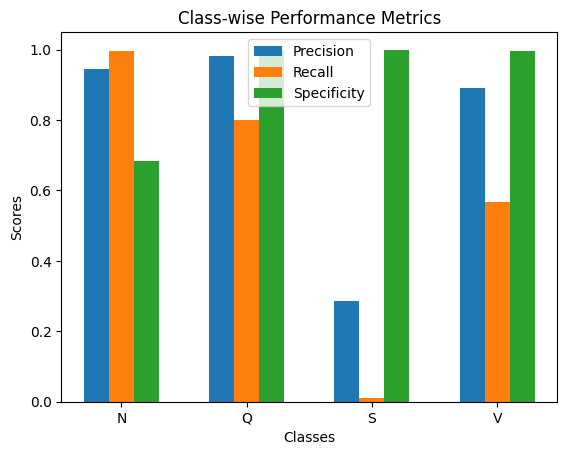

In [11]:
# prediction
y_pred = model.predict([x1_test, x2_test])
y_test = np.argmax(y_test_oh, axis=1)  

# get precision, recall, f1-score, specificity
precision, recall, f1, specificity = calc_metrics(y_test, y_pred, class_names)
global_metrics = calc_global_metrics(y_test, y_pred)

# report
print(classification_report(y_test, y_pred, target_names=class_names))
# get metric df
metric_df = get_metric_df(precision, recall, f1, specificity, class_names)
print(metric_df)


# histogram
plot_metric_hist(precision, recall, specificity, class_names)


In [16]:
# data export for colab
if colab:
    df_to_csv_colab(metric_df, file_name+'.csv')
    dict_to_json_colab(global_metrics, file_name+'.json')
else:
    metric_df.to_csv(gridsearch_path+file_name+'.csv', index=False)
    with open(gridsearch_path+file_name+'.json', 'w') as f:
        json.dump(global_metrics, f, indent=4)